In [12]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Loading the training data
train_data = scipy.io.loadmat("../../data/train.mat")
print(train_data.keys())

X_train = train_data['trainData']
labels = train_data['trainLabels']

print(X_train.shape)
print(labels.shape)
print(labels[0])

y_train = [label[0] for label in labels.flatten()]
print(y_train[:5])

classes, count = np.unique(y_train, return_counts=True)
print(classes, count)

dict_keys(['__header__', '__version__', '__globals__', 'trainData', 'trainLabels'])
(393, 5000)
(393, 1)
[array(['InnerRaceFault'], dtype='<U14')]
[np.str_('InnerRaceFault'), np.str_('InnerRaceFault'), np.str_('InnerRaceFault'), np.str_('InnerRaceFault'), np.str_('InnerRaceFault')]
['InnerRaceFault' 'Normal' 'OuterRaceFault'] [131 131 131]


The dataset has 393 training, 27 validation and 102 test signals, each a 5,000-sample vibration window labeled Normal, Inner Race Fault or Outer Race Fault. The training set has 131 per class and the test set 34 per class, so the classes are balanced. The data is stored sorted by class, so training data must be shuffled.

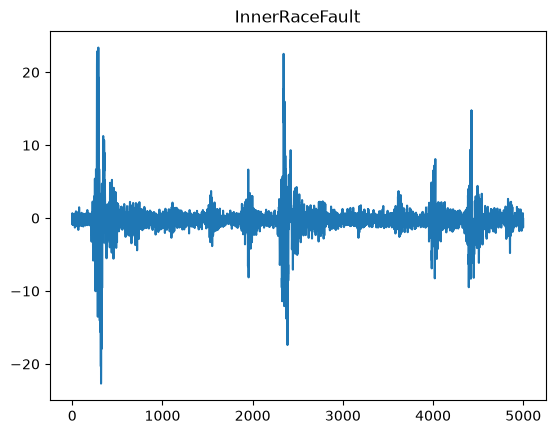

In [13]:
# Plotting one signal
plt.plot(X_train[0])
plt.title(y_train[0])
plt.show()

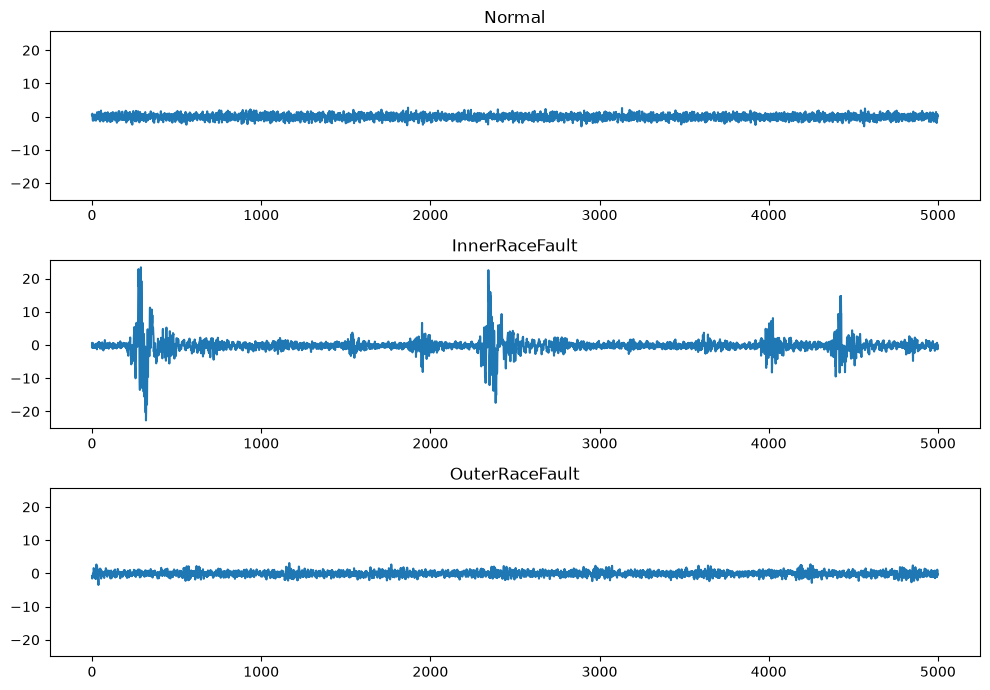

In [14]:
# Compare one signal from each class
class_names = ["Normal", "InnerRaceFault", "OuterRaceFault"]
y_train = np.array(y_train)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharey=True)

for ax, name in zip(axes, class_names):
    signal = X_train[y_train == name][0]
    ax.plot(signal)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [15]:
# Measure each class
for name in class_names:
    rows = X_train[y_train == name]
    print(name)
    print("  mean: ", rows.mean())
    print("  std:  ", rows.std())
    print("  max:  ", rows.max())

Normal
  mean:  -0.10336264926478216
  std:   0.7704540469339318
  max:   3.6498233400246125
InnerRaceFault
  mean:  -0.21479323618072374
  std:   1.887356830691482
  max:   39.31665
OuterRaceFault
  mean:  -0.1432061285412362
  std:   0.8985709166531455
  max:   16.21883


Inner Race signals are the spikiest and loudest. Normal and Outer Race have similar overall spread (std 0.77 vs 0.90), but Outer Race has occasional large spikes (max 16.2 vs 3.65), so the difference between those two is in rare impacts rather than overall loudness.

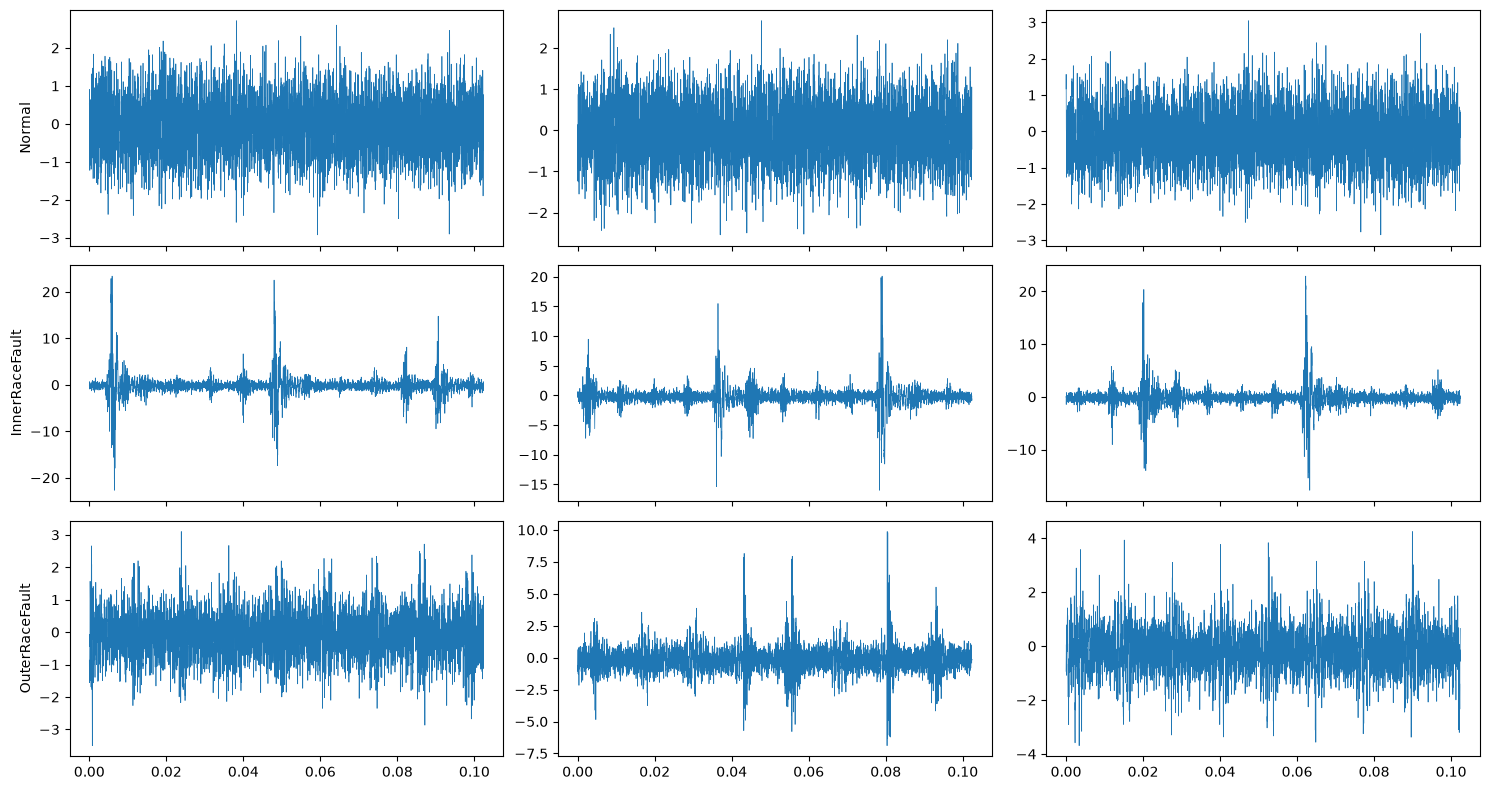

In [17]:
# 3 example signals per class
SAMPLE_RATE = 48828  # Hz
time = np.arange(X_train.shape[1]) / SAMPLE_RATE

n_examples = 3
fig, axes = plt.subplots(len(class_names), n_examples, figsize=(15, 8), sharex=True)

for i, name in enumerate(class_names):
    indexes = np.where(y_train == name)[0][:n_examples]
    for j, index in enumerate(indexes):
        axes[i, j].plot(time, X_train[index], linewidth=0.5)
        if j == 0:
            axes[i, j].set_ylabel(name)

plt.tight_layout()
plt.show()

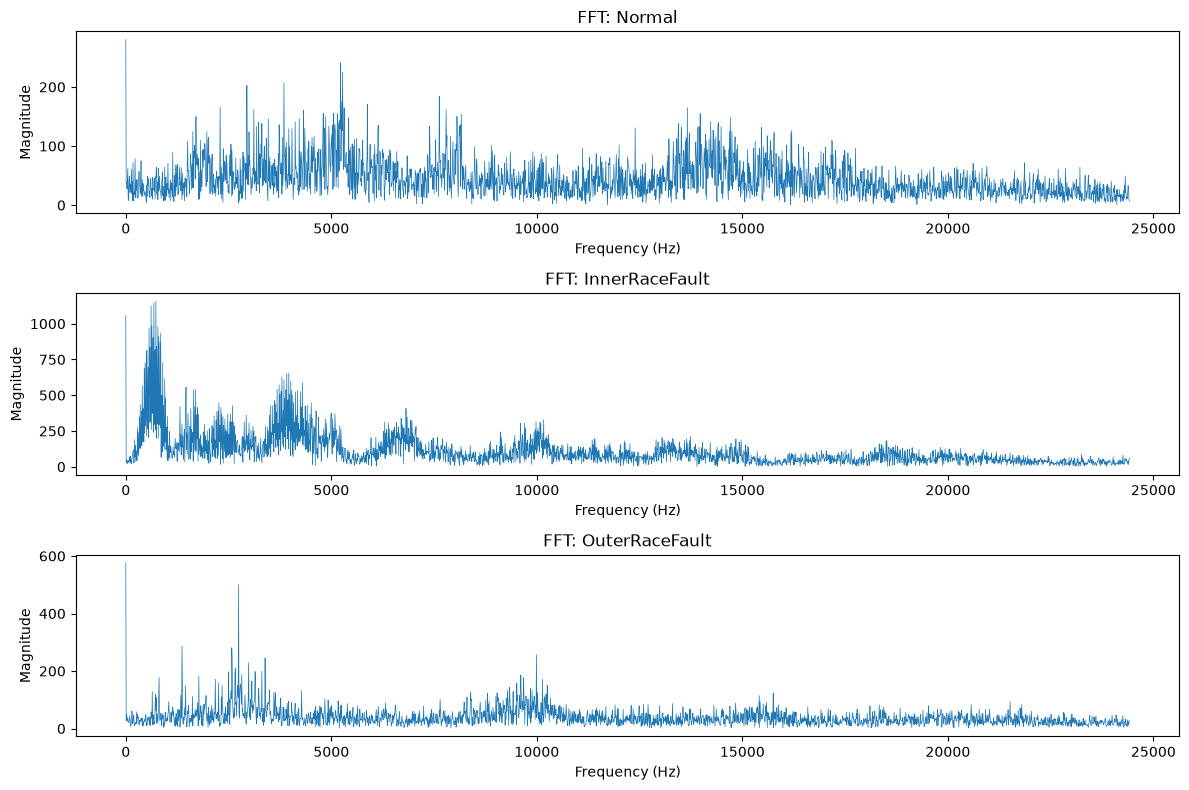

In [18]:
# Frequency spectrum, one signal per class
def plot_fft(signal, ax, title):
    freqs = np.fft.rfftfreq(len(signal), d=1 / SAMPLE_RATE)
    magnitudes = np.abs(np.fft.rfft(signal))
    ax.plot(freqs, magnitudes, linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")


fig, axes = plt.subplots(len(class_names), 1, figsize=(12, 8))
for i, name in enumerate(class_names):
    index = np.where(y_train == name)[0][0]
    plot_fft(X_train[index], axes[i], f"FFT: {name}")

plt.tight_layout()
plt.show()

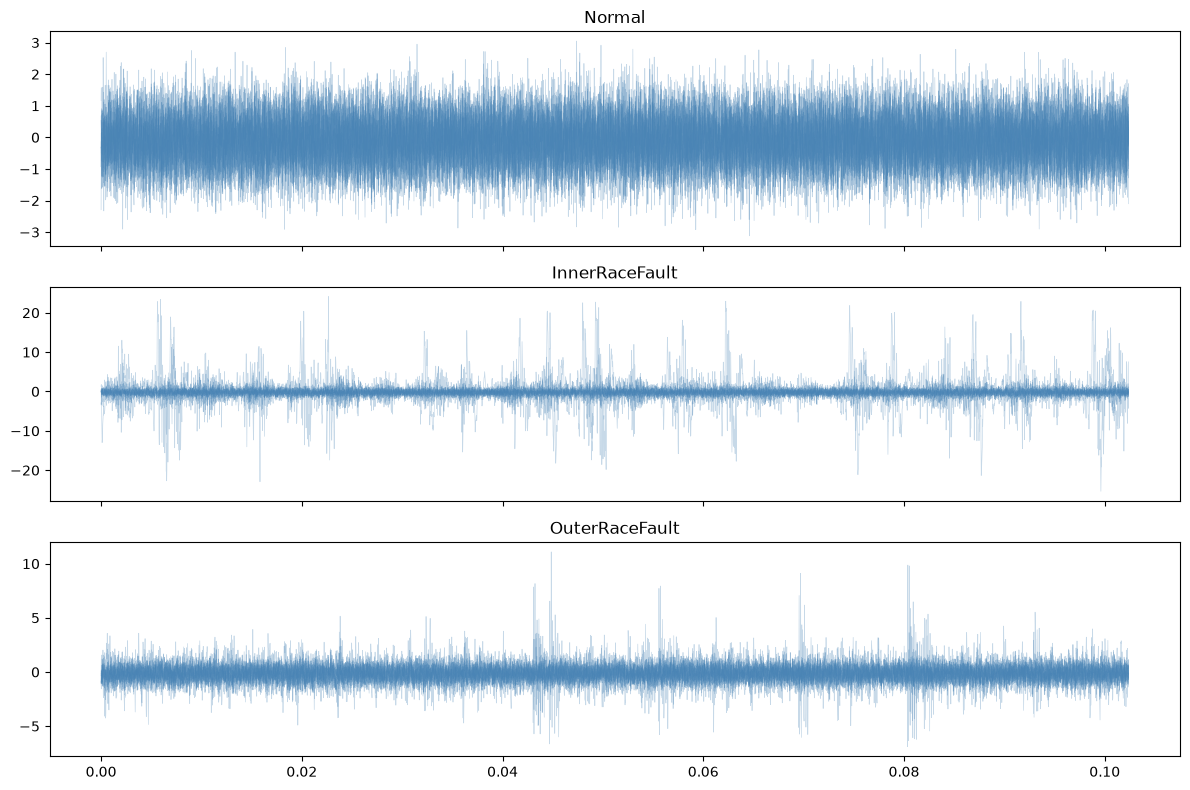

In [19]:
# 10 overlaid signals per class
fig, axes = plt.subplots(len(class_names), 1, figsize=(12, 8), sharex=True)

for i, name in enumerate(class_names):
    indexes = np.where(y_train == name)[0][:10]
    for index in indexes:
        axes[i].plot(time, X_train[index], alpha=0.3, linewidth=0.5, color="steelblue")
    axes[i].set_title(name)

plt.tight_layout()
plt.show()